Image shape: (1200, 1920)
Min pixel value: 0
Max pixel value: 209
Mean pixel value: 2.05721875


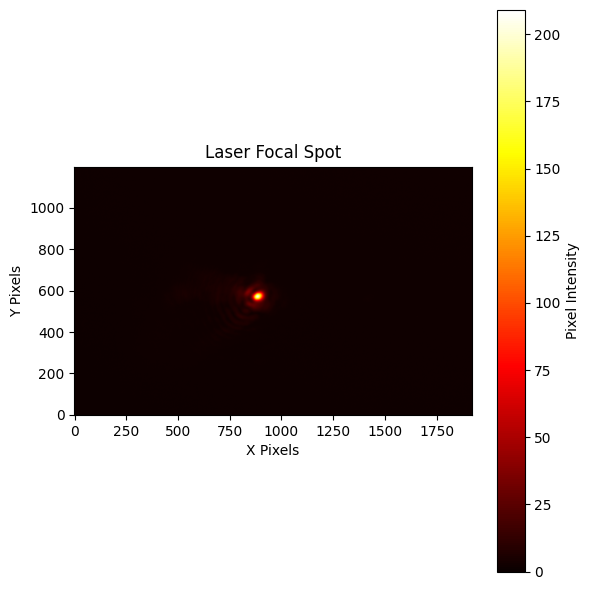

In [4]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load the image
#image_path = "20250627Optimized_focal_spot_wObjective_wPM_exptime3e3.tiff" ##TA2Diode
image_path = "Focal_Spot_Images/10mJ_New_Optimized_FocalSpotWithDPM_2025-07-17_1109AM.tiff" ##10mJ
try:
    img = Image.open(image_path)
    
    # Convert to grayscale (if it's not already)
    img_gray = img.convert("L")

    # Convert to NumPy array
    img_array = np.array(img_gray)

    # Show basic image stats
    print("Image shape:", img_array.shape)
    print("Min pixel value:", img_array.min())
    print("Max pixel value:", img_array.max())
    print("Mean pixel value:", img_array.mean())

    # Plot the image
    plt.figure(figsize=(6,6))
    plt.imshow(img_array, cmap='hot', origin='lower')
    plt.colorbar(label='Pixel Intensity')
    plt.title('Laser Focal Spot')
    plt.xlabel('X Pixels')
    plt.ylabel('Y Pixels')
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"File '{image_path}' not found.")
except Exception as e:
    print(f"An error occurred: {e}")


In [2]:
0.085416666667 ## um/px 


0.085416666667

In [3]:
def diffraction_limited_spot_size(wavelength_nm, beam_diameter_inch, focal_length_inch):
    # Convert inputs
    wavelength_um = wavelength_nm / 1000  # nm to microns
    beam_diameter_um = beam_diameter_inch * 25400  # inches to microns (1 inch = 25,400 microns)
    focal_length_um = focal_length_inch * 25_400

    # Calculate NA = D / (2f)
    NA = beam_diameter_um / (2 * focal_length_um)

    # Diffraction-limited spot diameter (Airy disk)
    spot_diameter_um = 1.22 * wavelength_um / NA

    return spot_diameter_um

# Parameters
wavelength_nm = 800
#beam_diameter_inch = 3 
beam_diameter_inch = 3.267 ##10mJ
focal_length_inch = 8

spot_size_um = diffraction_limited_spot_size(wavelength_nm, beam_diameter_inch, focal_length_inch)
print(f"Diffraction-limited spot diameter: {spot_size_um:.2f} µm")
print(f"Diffraction-limited spot Radius: {spot_size_um/2:.2f} µm")
df_lim_r = spot_size_um/2
df_lim_r

Diffraction-limited spot diameter: 4.78 µm
Diffraction-limited spot Radius: 2.39 µm


2.389960208142026

Index Radius (µm)     Avg Intensity   Area (pixels)   Total Energy    Normalized Energy 
140   6.641           24.2218         20097           486786.0000     0.2058            
141   6.364           25.7500         18481           475886.0000     0.2012            
142   6.087           27.4825         16889           464152.0000     0.1963            
143   5.811           29.3331         15397           451641.0000     0.1910            
144   5.534           31.3565         13965           437894.0000     0.1852            
145   5.257           33.5021         12621           422830.0000     0.1788            
146   4.981           35.9168         11289           405465.0000     0.1715            
147   4.704           38.4043         10097           387768.0000     0.1640            
148   4.427           41.2128         8961            369308.0000     0.1562            
149   4.151           44.6362         7845            350171.0000     0.1481            
150   3.874          

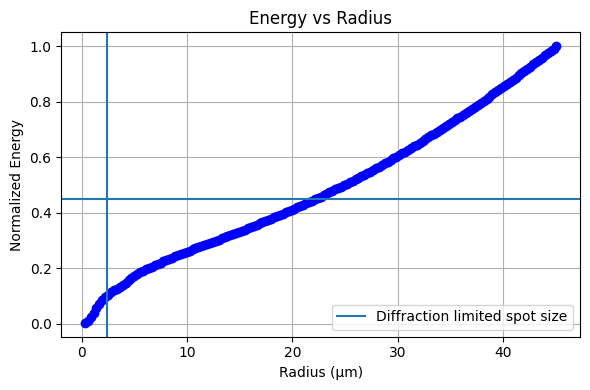

In [5]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

PIXEL_SIZE_MICRONS = 0.083  # microns per pixel

def load_image_as_array(path):
    """Load grayscale image as NumPy array of float64."""
    img = Image.open(path).convert("L")
    return np.array(img, dtype=np.float64)

def find_focal_spot_center(img_array):
    """Find center of brightest pixel (approx center of spot)."""
    max_pos = np.unravel_index(np.argmax(img_array), img_array.shape)
    return max_pos[1], max_pos[0]  # Return as (x, y)

def circular_mask(shape, center_x, center_y, radius):
    """Generate a circular mask of given radius (in pixels) centered at (x, y)."""
    Y, X = np.ogrid[:shape[0], :shape[1]]
    dist = np.sqrt((X - center_x)**2 + (Y - center_y)**2)
    return dist <= radius

def analyze_circular_apertures(img_array, center_x, center_y, n_steps=400, max_fraction=6.9):
    """
    Analyze concentric circular regions around focal spot center.
    Radius is in pixels internally.
    Returns a list of tuples: (radius_microns, avg_intensity, area_pixels, total_energy)
    """
    height, width = img_array.shape
    max_radius = min(center_x, center_y, width - center_x, height - center_y) * max_fraction
    radii_pixels = np.linspace(max_radius, max_radius / n_steps, n_steps)

    results = []

    for r_px in radii_pixels:
        mask = circular_mask(img_array.shape, center_x, center_y, r_px)
        masked_values = img_array[mask]
        avg_intensity = np.mean(masked_values)
        area_pixels = np.sum(mask)
        total_energy = avg_intensity * area_pixels

        radius_microns = r_px * PIXEL_SIZE_MICRONS
        results.append((radius_microns, avg_intensity, area_pixels, total_energy))

    return results

def plot_energy_vs_radius(results, normalize=True):
    """
    Plot total energy (avg intensity × area) as a function of radius in microns.

    Args:
        results: List of (radius_microns, avg_intensity, area_pixels, total_energy).
        normalize: If True, normalize energy to [0, 1].
    """
    radii = [r for r, _, _, _ in results]
    energies = [e for _, _, _, e in results]

    if normalize:
        max_energy = max(energies)
        energies = [e / max_energy for e in energies]

    plt.figure(figsize=(6,4))
    plt.plot(radii, energies, marker='o', color='blue')
    plt.xlabel("Radius (µm)")
    plt.ylabel("Normalized Energy" if normalize else "Total Energy")
    plt.title("Energy vs Radius")
    plt.grid(True)
    plt.tight_layout()
    plt.axvline(x = df_lim_r, label = "Diffraction limited spot size")##TA2 Diode
    plt.axhline(y = .45) 
    #plt.axvline(x = 2.39, label = "Diffraction limited spot size")## 10mJ
    #plt.axhline(y = .36)
    plt.legend()
    plt.show()

def main(image_path):
    img_array = load_image_as_array(image_path)
    center_x, center_y = find_focal_spot_center(img_array)
    step_count = 163
    results = analyze_circular_apertures(img_array, center_x, center_y, n_steps=step_count, max_fraction=0.95)

    # Calculate max total energy for normalization
    max_energy = max(energy for _, _, _, energy in results)

    print(f"{'Index':<5} {'Radius (µm)':<15} {'Avg Intensity':<15} {'Area (pixels)':<15} {'Total Energy':<15} {'Normalized Energy':<18}")
    for i, (r, avg, area, energy) in enumerate(results, 1):
        norm_energy = energy / max_energy if max_energy != 0 else 0
        if (i > step_count * 6/7):
            print(f"{i:<5} {r:<15.3f} {avg:<15.4f} {int(area):<15} {energy:<15.4f} {norm_energy:<18.4f}")

    plot_energy_vs_radius(results, normalize=True)



if __name__ == "__main__":
    #image_path = #"20250627Optimized_focal_spot_wObjective_wPM_exptime3e3.tiff"  # update with your path if needed
    ##image_path = "/10mJ_New_Optimized_FocalSpotWithDPM_2025-07-17_1109AM.tiff" ##10mJ
    image_path = "Focal_Spot_Images/10mJ_New_Optimized_FocalSpotWithDPM_2025-07-17_1109AM.tiff"
    main(image_path)


In [6]:
print("Strehl ratio:  0.7224  ")

Strehl ratio:  0.7224  


In [7]:
!pwd

/Users/jeremyrebenstock/Documents/Research_2/Calculations/Laser_Calculations


789079.0
1.0


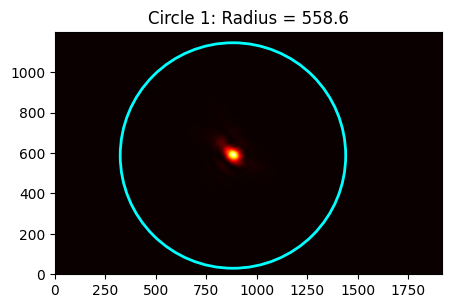

789079.0
0.9999987326997677
789079.0
0.9999974653995354
789079.0
0.9999974653995354
789079.0
0.9999974653995354
789079.0
0.9999974653995354
789079.0
0.9999936634988386
789079.0
0.9999936634988386
789079.0
0.9999797231962833
789079.0
0.9999632482932634


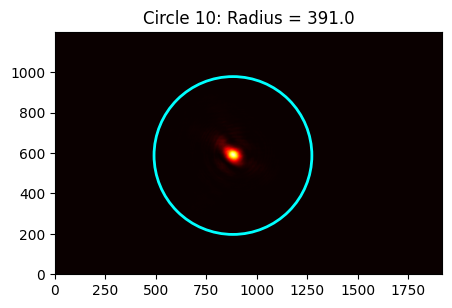

789079.0
0.9999379022886175
789079.0
0.999726263149824
789079.0
0.9994449224982543
789079.0
0.9987377689686331
789079.0
0.9973855596207731
789079.0
0.9960346175731454
789079.0
0.9937040524459528
789079.0
0.988911122967409
789079.0
0.9829484753744555


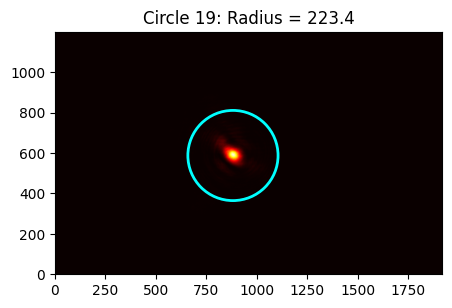

789079.0
0.9750861447332904
789079.0
0.9632711046675935
789079.0
0.9484842455571623
789079.0
0.9297877652300973
789079.0
0.9018437951079676
789079.0
0.8700890531873234
789079.0
0.8198646776811954
789079.0
0.7581839080751104
789079.0
0.6942498786560027


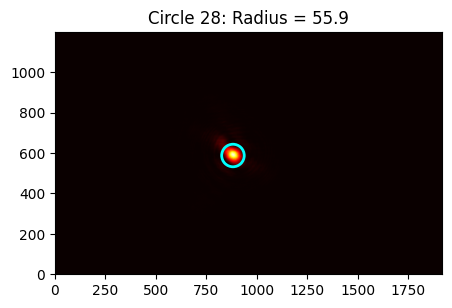

789079.0
0.5282538250289261
789079.0
0.20647869224754428
Index Radius     Avg Intensity   Area       Total Energy    rati           
1     558.60     0.8050          980249     789079.0000     1.0000         
2     539.98     0.8614          916009     789078.0000     1.0000         
3     521.36     0.9240          853965     789077.0000     1.0000         
4     502.74     0.9938          794005     789077.0000     1.0000         
5     484.12     1.0717          736305     789077.0000     1.0000         
6     465.50     1.1591          680777     789077.0000     1.0000         
7     446.88     1.2577          627381     789074.0000     1.0000         
8     428.26     1.3694          576201     789074.0000     1.0000         
9     409.64     1.4969          527129     789063.0000     1.0000         
10    391.02     1.6429          480293     789050.0000     1.0000         
11    372.40     1.8109          435709     789030.0000     1.0000         
12    353.78     2.0063        

In [10]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def load_image_as_array(path):
    """Load grayscale image as NumPy array of float64."""
    img = Image.open(path).convert("L")
    return np.array(img, dtype=np.float64)

def find_focal_spot_center(img_array):
    """Find center of brightest pixel (approx center of spot)."""
    max_pos = np.unravel_index(np.argmax(img_array), img_array.shape)
    return max_pos[1], max_pos[0]  # Return as (x, y)

def circular_mask(shape, center_x, center_y, radius):
    """Generate a circular mask of given radius centered at (x, y)."""
    Y, X = np.ogrid[:shape[0], :shape[1]]
    dist = np.sqrt((X - center_x)**2 + (Y - center_y)**2)
    return dist <= radius

def analyze_circular_apertures(img_array, center_x, center_y, n_steps=50, max_fraction=0.95, plot_every=None):
    """Analyze concentric circular regions around focal spot center."""
    height, width = img_array.shape
    max_radius = min(center_x, center_y, width - center_x, height - center_y) * max_fraction
    radii = np.linspace(max_radius, max_radius / n_steps, n_steps)

    results = []

    energy_ratio = 1
    
    for i, r in enumerate(radii):
        mask = circular_mask(img_array.shape, center_x, center_y, r)
        masked_values = img_array[mask]
        avg_intensity = np.mean(masked_values)
        area = np.sum(mask)
        energy = avg_intensity * area
        
        results.append((r, avg_intensity, area, energy,energy_ratio))
        
        energy_ratio = energy/results[0][3] ##energy of current value divided by first encircled
        print(results[0][3])
        print(energy_ratio)
        
        if plot_every is not None and i % plot_every == 0:
            plt.figure(figsize=(5,5))
            plt.imshow(img_array, cmap='hot', origin='lower')
            circle = plt.Circle((center_x, center_y), r, color='cyan', linewidth=2, fill=False)
            plt.gca().add_patch(circle)
            plt.title(f"Circle {i+1}: Radius = {r:.1f}")
            plt.axis("on")
            plt.show()

    return results

# --- Main usage ---
##image_path =  "20250627Optimized_focal_spot_wObjective_wPM_exptime3e3.tiff"
##image_path = "/Users/jeremyrebenstock/Documents/Research_2/TA2/10mJ_New_Optimized_FocalSpotWithDPM_2025-07-17_1109AM.tiff"
image_path = "Focal_Spot_Images/20250627Optimized_focal_spot_wObjective_wPM_exptime3e3.tiff"

img_array = load_image_as_array(image_path)
center_x, center_y = find_focal_spot_center(img_array)

# Analyze ~30 decreasing apertures, show every 10th circle
results = analyze_circular_apertures(img_array, center_x, center_y, n_steps=30, plot_every=9)

# Print summary table
print(f"{'Index':<5} {'Radius':<10} {'Avg Intensity':<15} {'Area':<10} {'Total Energy':<15} {'ratio':<15.4}")
for i, (r, avg, area, energy,energy_ratio) in enumerate(results):
    print(f"{i+1:<5} {r:<10.2f} {avg:<15.4f} {int(area):<10} {energy:<15.4f} {energy_ratio:<15.4f}")


### Combining above codes to make a useful program to calculate the strehl ratio

In [ ]:
## diffraction limit spot size? 
## make a circle of that size on plot 
## calculate the encircled energy over:
    #an area much larger than the spot
    #the area of the diffraction limited spot
## take the ratio of the encircled energy

## So we need to input:
    ## the diffraction limited spot size
    ## the pixels/wavelength
    ## or 
        #specify the radius we want in pixels?

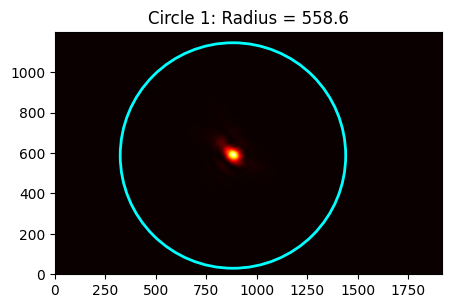

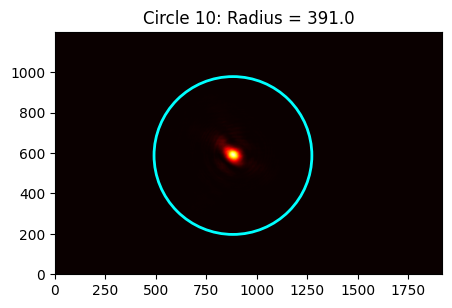

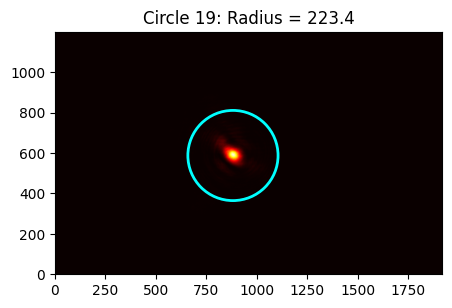

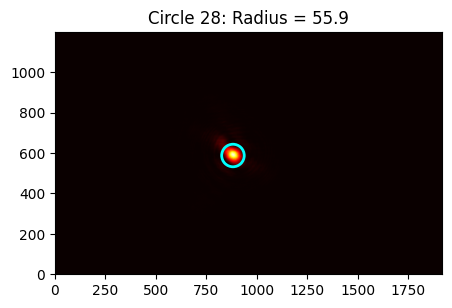

Index Radius     Avg Intensity   Area       Total Energy    rati           
1     558.60     0.8050          980249     789079.0000     1.0000         
2     539.98     0.8614          916009     789078.0000     1.0000         
3     521.36     0.9240          853965     789077.0000     1.0000         
4     502.74     0.9938          794005     789077.0000     1.0000         
5     484.12     1.0717          736305     789077.0000     1.0000         
6     465.50     1.1591          680777     789077.0000     1.0000         
7     446.88     1.2577          627381     789074.0000     1.0000         
8     428.26     1.3694          576201     789074.0000     1.0000         
9     409.64     1.4969          527129     789063.0000     1.0000         
10    391.02     1.6429          480293     789050.0000     1.0000         
11    372.40     1.8109          435709     789030.0000     1.0000         
12    353.78     2.0063          393189     788863.0000     0.9999         
13    335.16

In [11]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import csv
import os
from datetime import datetime

def load_image_as_array(path):
    """Load grayscale image as NumPy array of float64."""
    img = Image.open(path).convert("L")
    return np.array(img, dtype=np.float64)

def find_focal_spot_center(img_array):
    """Find center of brightest pixel (approx center of spot)."""
    max_pos = np.unravel_index(np.argmax(img_array), img_array.shape)
    return max_pos[1], max_pos[0]  # Return as (x, y)

def circular_mask(shape, center_x, center_y, radius):
    """Generate a circular mask of given radius centered at (x, y)."""
    Y, X = np.ogrid[:shape[0], :shape[1]]
    dist = np.sqrt((X - center_x)**2 + (Y - center_y)**2)
    return dist <= radius

def analyze_circular_apertures(img_array, center_x, center_y, n_steps=50, max_fraction=0.95, plot_every=None):
    """Analyze concentric circular regions around focal spot center."""
    height, width = img_array.shape
    max_radius = min(center_x, center_y, width - center_x, height - center_y) * max_fraction
    radii = np.linspace(max_radius, max_radius / n_steps, n_steps)

    results = []

    energy_ratio = 1
    
    for i, r in enumerate(radii):
        mask = circular_mask(img_array.shape, center_x, center_y, r)
        masked_values = img_array[mask]
        avg_intensity = np.mean(masked_values)
        area = np.sum(mask)
        energy = avg_intensity * area
        
        results.append((r, avg_intensity, area, energy,energy_ratio))
        
        energy_ratio = energy/results[0][3] ##energy of current value divided by first encircled
        ##print(results[0][3])
        
        if plot_every is not None and i % plot_every == 0:
            plt.figure(figsize=(5,5))
            plt.imshow(img_array, cmap='hot', origin='lower')
            circle = plt.Circle((center_x, center_y), r, color='cyan', linewidth=2, fill=False)
            plt.gca().add_patch(circle)
            plt.title(f"Circle {i+1}: Radius = {r:.1f}")
            plt.axis("on")
            plt.show()

    return results

# --- Main usage ---
image_path =  "Focal_Spot_Images/20250627Optimized_focal_spot_wObjective_wPM_exptime3e3.tiff"
img_array = load_image_as_array(image_path)
center_x, center_y = find_focal_spot_center(img_array)

# Analyze ~30 decreasing apertures, show every 10th circle
results = analyze_circular_apertures(img_array, center_x, center_y, n_steps=30, plot_every=9)

# Print summary table
print(f"{'Index':<5} {'Radius':<10} {'Avg Intensity':<15} {'Area':<10} {'Total Energy':<15} {'ratio':<15.4}")
for i, (r, avg, area, energy,energy_ratio) in enumerate(results):
    print(f"{i+1:<5} {r:<10.2f} {avg:<15.4f} {int(area):<10} {energy:<15.4f} {energy_ratio:<15.4f}")


### 80% of energy

In [65]:
import numpy as np
import matplotlib.pyplot as plt

def _encircled_energy_core(img, fraction=0.80):
    """
    Core computation for encircled-energy radius.
    Returns center_x, center_y, radius_px, energy_encircled, total_energy
    """
    center_x, center_y = find_focal_spot_center(img)

    total_energy = np.sum(img)
    if total_energy <= 0:
        raise ValueError("Total energy is zero or negative.")

    Y, X = np.indices(img.shape)
    r = np.sqrt((X - center_x)**2 + (Y - center_y)**2)

    r_flat = r.flatten()
    img_flat = img.flatten()

    sort_idx = np.argsort(r_flat)
    r_sorted = r_flat[sort_idx]
    img_sorted = img_flat[sort_idx]

    cumulative_energy = np.cumsum(img_sorted)

    target_energy = fraction * total_energy
    idx = np.searchsorted(cumulative_energy, target_energy)

    radius_px = r_sorted[idx]
    energy_encircled = cumulative_energy[idx]

    return center_x, center_y, radius_px, energy_encircled, total_energy

def encircled_energy_radius_px(img, fraction=0.80):
    """
    Returns
    -------
    radius_px : float
        Radius containing target energy (pixels)
    """
    _, _, radius_px, _, _ = _encircled_energy_core(img, fraction)
    return radius_px

def encircled_energy_radius_um(img, um_per_pixel, fraction=0.80):
    """
    Returns
    -------
    radius_um : float
        Radius containing target energy (µm)
    """
    _, _, radius_px, _, _ = _encircled_energy_core(img, fraction)
    return radius_px * um_per_pixel

def encircled_energy_value(
    img,
    um_per_pixel,
    fraction=0.80,
    plot=True
):
    """
    Returns
    -------
    energy_encircled : float
        Energy inside the encircled-energy radius
    """
    center_x, center_y, radius_px, energy_encircled, total_energy = \
        _encircled_energy_core(img, fraction)

    radius_um = radius_px * um_per_pixel

    print(f"{fraction*100:}% encircled-energy radius:")
    print(f"  Radius = {radius_px:.2f} pixels")
    print(f"  Radius = {radius_um:.2f} µm")
    print(f"  Energy enclosed = {energy_encircled:.3e}")

    if plot:
        plt.figure(figsize=(5,5))
        plt.imshow(img, cmap="hot", origin="lower", norm="log")
        circle = plt.Circle(
            (center_x, center_y),
            radius_px,
            color="cyan",
            fill=False,
            lw=2
        )
        plt.gca().add_patch(circle)
        plt.title(f"{fraction*100:}% Encircled Energy")
        plt.colorbar(label="Counts")
        plt.show()

    return energy_encircled

80.0% encircled-energy radius:
  Radius = 815.25 pixels
  Radius = 69.64 µm
  Energy enclosed = 3.792e+06


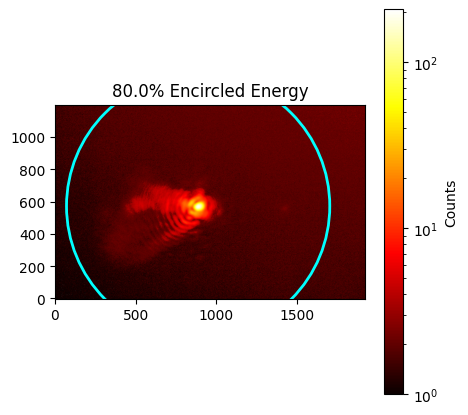

99.95% encircled-energy radius:
  Radius = 336.59 pixels
  Radius = 28.75 µm
  Energy enclosed = 7.887e+05


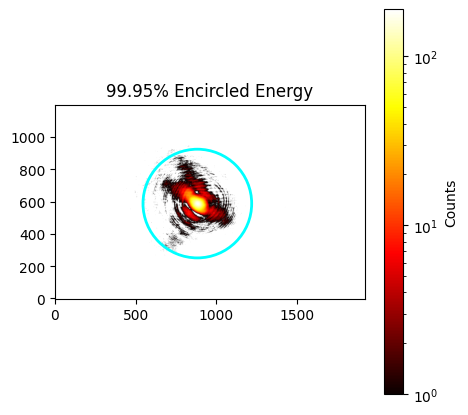

In [67]:
um_per_pixel=0.085416666667

image_path_test_2 = "Focal_Spot_Images/Focal_Spot_Tests/20250627Optimized_focal_spot_wObjective_wPM_exptime3e3.tiff"
image_path_test_1 = "Focal_Spot_Images/Focal_Spot_Tests/10mJ_New_Optimized_FocalSpotWithDPM_2025-07-17_1109AM.tiff"

img_1 = load_image_as_array(image_path_test_1)
img_2 = load_image_as_array(image_path_test_2)



r80_px = encircled_energy_radius_px(img =img_1,fraction = .8)
r80_um = encircled_energy_radius_um(img = img_1, um_per_pixel = um_per_pixel,fraction = .8)
E80    = encircled_energy_value(img = img_1, um_per_pixel=um_per_pixel, plot=True,fraction = .8)
## img 2 
r80_px = encircled_energy_radius_px(img =img_2,fraction = .9995)
r80_um = encircled_energy_radius_um(img = img_2, um_per_pixel = um_per_pixel,fraction = .9995)
E80    = encircled_energy_value(img = img_2, um_per_pixel=um_per_pixel, plot=True,fraction = .9995)

## Functioning Code: 
Wrote into strehl_v1.py in 
Documents/Research_2/Calculations/Optical_Calculations/strehl_v1.py

99.95% encircled-energy radius:
  Radius = 336.59 pixels
  Radius = 28.75 µm
  Energy enclosed = 7.887e+05
296790.0


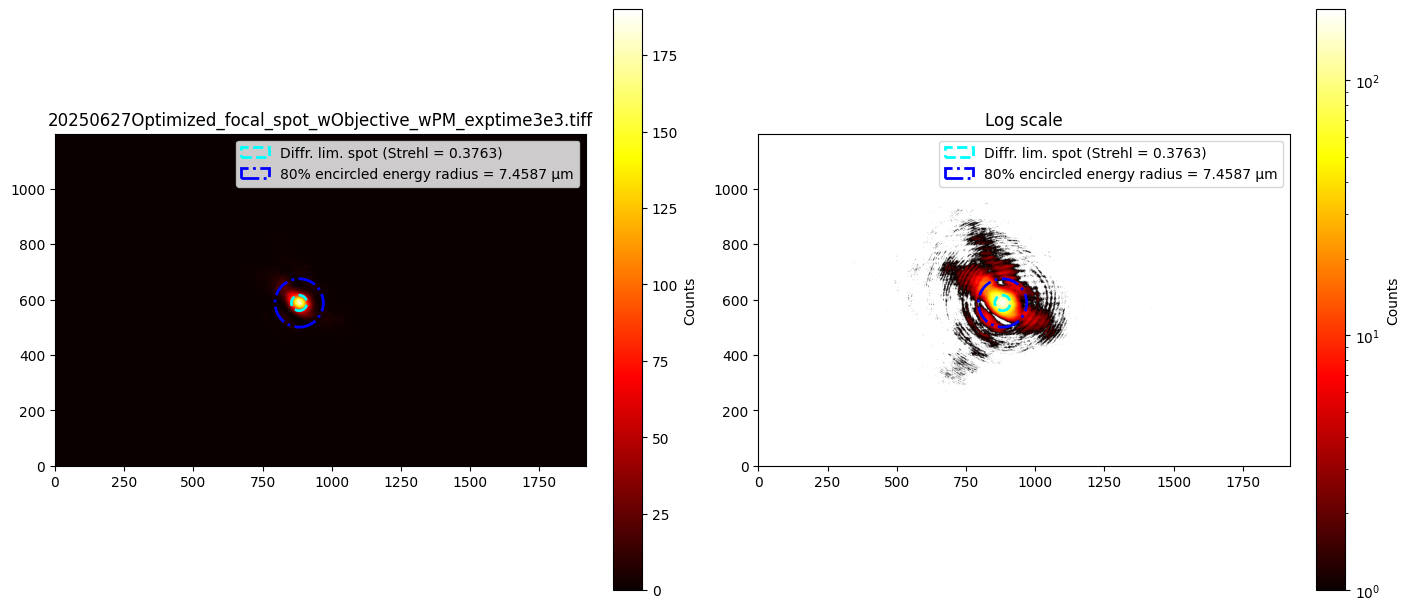

Strehl ratio from = 0.3763
80% enclosed enregy radius = 7.4587


In [110]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import csv
import os
from datetime import datetime

##Jeremy Rebenstock 03/03
##jrebenst@umich.edu



def load_image_as_array(path):
    """Load grayscale image as NumPy array of float64."""
    img = Image.open(path).convert("L")
    return np.array(img, dtype=np.float64)

def find_focal_spot_center(img_array):
    """Find center of brightest pixel (approx focal spot center)."""
    y, x = np.unravel_index(np.argmax(img_array), img_array.shape)
    return x, y

def circular_mask(shape, center_x, center_y, radius_px):
    """Boolean circular mask."""
    Y, X = np.ogrid[:shape[0], :shape[1]]
    return (X - center_x)**2 + (Y - center_y)**2 <= radius_px**2


def diffraction_limited_spot_size(wavelength_nm, beam_diameter_inch, focal_length_inch):
    wavelength_um = wavelength_nm / 1000
    beam_diameter_um = beam_diameter_inch * 25_400
    focal_length_um = focal_length_inch * 25_400

    NA = beam_diameter_um / (2 * focal_length_um)
    spot_diameter_um = 1.22 * wavelength_um / NA
    return spot_diameter_um / 2  # radius in µm

def load_background_image(path, target_shape):
    """
    Load background image and verify it matches the focal spot image shape.
    """
    bkg = load_image_as_array(path)

    if bkg.shape != target_shape:
        raise ValueError(
            f"Background image shape {bkg.shape} does not match focal image shape {target_shape}"
        )

    return bkg



import numpy as np
import matplotlib.pyplot as plt

def _encircled_energy_core(img, fraction=0.80):
    """
    Core computation for encircled-energy radius.
    Returns center_x, center_y, radius_px, energy_encircled, total_energy
    """
    center_x, center_y = find_focal_spot_center(img)

    total_energy = np.sum(img)
    if total_energy <= 0:
        raise ValueError("Total energy is zero or negative.")

    Y, X = np.indices(img.shape)
    r = np.sqrt((X - center_x)**2 + (Y - center_y)**2)

    r_flat = r.flatten()
    img_flat = img.flatten()

    sort_idx = np.argsort(r_flat)
    r_sorted = r_flat[sort_idx]
    img_sorted = img_flat[sort_idx]

    cumulative_energy = np.cumsum(img_sorted)

    target_energy = fraction * total_energy
    idx = np.searchsorted(cumulative_energy, target_energy)

    radius_px = r_sorted[idx]
    energy_encircled = cumulative_energy[idx]

    return center_x, center_y, radius_px, energy_encircled, total_energy

def encircled_energy_radius_px(img, fraction=0.80):
    """
    Returns
    -------
    radius_px : float
        Radius containing target energy (pixels)
    """
    _, _, radius_px, _, _ = _encircled_energy_core(img, fraction)
    return radius_px

def encircled_energy_radius_um(img, um_per_pixel, fraction=0.80):
    """
    Returns
    -------
    radius_um : float
        Radius containing target energy (µm)
    """
    _, _, radius_px, _, _ = _encircled_energy_core(img, fraction)
    return radius_px * um_per_pixel

def encircled_energy_value(
    img,
    um_per_pixel,
    fraction=0.80,
    plot=True
):
    """
    Returns
    -------
    energy_encircled : float
        Energy inside the encircled-energy radius
    """
    center_x, center_y, radius_px, energy_encircled, total_energy = \
        _encircled_energy_core(img, fraction)

    radius_um = radius_px * um_per_pixel

    print(f"{fraction*100:}% encircled-energy radius:")
    print(f"  Radius = {radius_px:.2f} pixels")
    print(f"  Radius = {radius_um:.2f} µm")
    print(f"  Energy enclosed = {energy_encircled:.3e}")

    if plot:
        plt.figure(figsize=(5,5))
        plt.imshow(img, cmap="hot", origin="lower", norm="log")
        circle = plt.Circle(
            (center_x, center_y),
            radius_px,
            color="cyan",
            fill=False,
            lw=2
        )
        plt.gca().add_patch(circle)
        plt.title(f"{fraction*100:}% Encircled Energy")
        plt.colorbar(label="Counts")
        plt.show()

    return energy_encircled



def append_strehl_to_csv(
    csv_path,
    image_path,
    strehl_value,
    diffraction_radius_um,
    um_per_pixel,
    r80_um,
    r9995_um,
    background_image_path=None
):
    """
    Append a Strehl calculation to a CSV file.
    Creates the file with headers if it does not exist.
    """
    file_exists = os.path.isfile(csv_path)

    with open(csv_path, mode="a", newline="") as f:
        writer = csv.writer(f)

        if not file_exists:
            writer.writerow([
                "image_file",
                "strehl_ratio",
                "diffraction_limit_radius_um",
                "EE.8_radius_um",## encircled energy 80%
                "EE.9995_radius_um",## encircled energy 99.95%
                "background image",
                "um_per_pixel",
                "datetime_run",
            ])

        writer.writerow([
            os.path.abspath(image_path),  
            f"{strehl_value:.6f}",
            f"{diffraction_radius_um:.4f}",
            f"{r80_um:.6f}",
            f"{r9995_um:.6f}",
            f"{background_image_path}",
            f"{um_per_pixel:.4f}",
            datetime.now().isoformat(timespec="seconds"),
        ])
        
## Next will update the strehl csv
def strehl_from_image(
    image_path,
    um_per_pixel,
    diffraction_radius_um,
    background_image_path=None,
    plot=True
):
    
    img = load_image_as_array(image_path)
    # Optional background subtraction
    if background_image_path is not None:
        bkg = load_background_image(background_image_path, img.shape)
        img = img - bkg
        img[img < 0] = 0.0  # prevent negative intensities

    cx, cy = find_focal_spot_center(img)
    radius_px = diffraction_radius_um / um_per_pixel ## radius of diffraction limited spot in pixels
    
    ## calculate values based on encircled energies
    r80_px = encircled_energy_radius_px(img =img,fraction = .8)
    r80_um = encircled_energy_radius_um(img = img, um_per_pixel = um_per_pixel,fraction = .8) ##radius of 80% energy included
    r9995_um = encircled_energy_radius_um(img = img, um_per_pixel = um_per_pixel,fraction = .9995) ##radius of 99.95% energy included
    
    E9995    = encircled_energy_value(img = img, um_per_pixel=um_per_pixel, plot=False,fraction = .9995) ## the Energy within the circle of which contains 99.95% of energy
    
    spot_mask = circular_mask(img.shape, cx, cy, radius_px) ## diffraction limited spot 
    ##total_mask = np.ones_like(img, dtype=bool) 
    
    energy_spot = np.sum(img[spot_mask]) ## calculate energy based on radius
    
    print(energy_spot)
    strehl = energy_spot / E9995
    

    # ---- CSV WRITE ---- ## Add other values as desired? 
    csv_path="Focal_Spot_Data/strehl_data.csv"
    append_strehl_to_csv(
        csv_path, ## from current folder
        image_path,
        strehl,
        diffraction_radius_um,
        um_per_pixel,
        r80_um,
        r9995_um,
        background_image_path
    )

    if plot:
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
        # -------- Left: Linear scale --------
        im0 = axes[0].imshow(img, cmap="hot", origin="lower")
        circle_strehl_0 = plt.Circle((cx, cy),radius_px,color="cyan",linestyle="--",fill=False,lw=2,
            label=f"Diffr. lim. spot (Strehl = {strehl:.4f})"
        )
        circle_80_0 = plt.Circle((cx, cy),r80_px,color="blue", linestyle="-.",fill=False,lw=2,
            label=f"80% encircled energy radius = {np.round(r80_um, 4)} µm"
        )
        axes[0].add_patch(circle_strehl_0)
        axes[0].add_patch(circle_80_0)
        axes[0].set_title(os.path.basename(image_path))
        fig.colorbar(im0, ax=axes[0], label="Counts")
        axes[0].legend()
        
        # -------- Right: Log scale --------
        im1 = axes[1].imshow(img, cmap="hot", origin="lower", norm="log")
        circle_strehl_1 = plt.Circle((cx, cy),radius_px,color="cyan",linestyle="--",fill=False,lw=2,
            label=f"Diffr. lim. spot (Strehl = {strehl:.4f})"
        )
        circle_80_1 = plt.Circle((cx, cy),r80_px,color="blue",linestyle="-.",fill=False,lw=2,
            label=f"80% encircled energy radius = {np.round(r80_um, 4)} µm"
        )
        axes[1].add_patch(circle_strehl_1)
        axes[1].add_patch(circle_80_1)
        axes[1].set_title("Log scale")
        fig.colorbar(im1, ax=axes[1], label="Counts")
        axes[1].legend()
        
        
        plt.show()




    return strehl,r80_um

## change based on system 
##image_path = "Focal_Spot_Images/Focal_Spot_Tests/10mJ_New_Optimized_FocalSpotWithDPM_2025-07-17_1109AM.tiff"
image_path = "Focal_Spot_Images/Focal_Spot_Tests/20250627Optimized_focal_spot_wObjective_wPM_exptime3e3.tiff"

## Optical parameters for Diffraction spot size calculation
## TA2 values 
wavelength_nm = 800
beam_diameter_inch = 3.267
focal_length_inch = 8
##
# Camera calibration
um_per_pixel = 0.085416666667 

# Calculated Diffraction limit spot radius
spot_radius_um = diffraction_limited_spot_size(
    wavelength_nm,
    beam_diameter_inch,
    focal_length_inch
)
#### Can enter diffraction limited spot radius by hand if you want 
## spot_radius_um = 2.7

strehl,r80_um = strehl_from_image(
    image_path,
    um_per_pixel,
    spot_radius_um,
    background_image_path=None,
    plot=True,
)


print(f"Strehl ratio from = {strehl:.4f}")
print(f"80% enclosed enregy radius = {r80_um:.4f}")
